"""
Hotel Occupancy Forecasting Project

In this project, I am building a Machine Learning model to predict hotel Occupancy Percentage.

As a Revenue Management Intern, this type of model can help understand future demand,
support ADR decisions, improve staffing planning, manage inventory, and identify high-demand dates.

Instead of only looking at historical averages, this model learns from seasonality, holidays,
events, group demand, booking pace, pricing, competitor data, and weather-related factors.
"""

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df=pd.read_csv("D:/Git Hub IMP/hotel_occupancy_forecasting/hotel_5years_data.csv")

In [3]:
print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1827, 147)

First 5 Rows:


,Date,Year,Quarter,Month,MonthName,Day,WeekOfMonth,DayOfWeek,DOW_num,IsWeekend,...,Occ_Lag_14,Occ_Lag_365,Occ_RollingMean_7,Occ_RollingMean_30,Occ_RollingStd_30,Rolling_ADR_7,Rolling_ADR_14,Rolling_ADR_30,ADR_Diff_vs_LastWeek,Occ_Diff_vs_LastWeek
0,2021-07-05,2021,3,7,July,5,1,Monday,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021-07-06,2021,3,7,July,6,1,Tuesday,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021-07-07,2021,3,7,July,7,1,Wednesday,2,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021-07-08,2021,3,7,July,8,2,Thursday,3,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2021-07-09,2021,3,7,July,9,2,Friday,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Column Names:
['Date', 'Year', 'Quarter', 'Month', 'MonthName', 'Day', 'WeekOfMonth', 'DayOfWeek', 'DOW_num', 'IsWeekend', 'WeekOfYear', 'Season', 'EventName', 'IsSpecialEvent', 'IsHoliday', 'ConventionFlag', 'ConventionName', 'Days_Until_Next_Holiday', 'Days_Since_Last_Holiday', 'Weekend_Before_Holiday_Flag', 'CruiseShipInPort', 'Cruise_Passenger_Volume', 'HurricaneSeasonFlag', 'StormPhase', 'StormImpact', 'TempF', 'PrecipInches', 'RainFlag', 'Pool_Closed', 'Waterpark_Closed', 'Spa_Closed', 'Restaurant_Closed', 'Construction_Flag', 'Renovation_Flag', 'Power_Outage_Flag', 'OOO_Rooms', 'Maintenance_Rooms', 'Blocked_Rooms', 'Available_Rooms_For_Sale', 'RoomsAvailable', 'Occupancy_Pct', 'RoomsSold', 'ADR', 'RevPAR', 'Room_Revenue', 'BAR_Level', 'Minimum_Stay_Nights', 'LOS_Restriction_Nights', 'CTA_Flag', 'CTD_Flag', 'Promotion_Running', 'Discount_Pct', 'Flash_Sale_Flag', 'Package_Promotion_Flag', 'Group_Rooms', 'Group_ADR', 'Group_Revenue', 'Group_Wash_Pct', 'Group_Pickup', 'Num_Groups',

In [4]:
"""
The Date column is important because this is a time-based hotel forecasting problem.

I am converting Date into proper datetime format and sorting the dataset by date.
This is important because future dates should not be mixed with past dates during model training.
"""

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

print("Minimum Date:", df["Date"].min())
print("Maximum Date:", df["Date"].max())

Minimum Date: 2021-07-05 00:00:00
Maximum Date: 2026-07-05 00:00:00


In [5]:
"""
The dataset has 147 columns, but using all columns is not good.

Some columns are duplicate information.
Some columns can cause data leakage.
Some columns make the model harder to explain.

For this project, I am creating a realistic 14-day occupancy forecasting model.
So I am selecting only the most useful columns that make sense for hotel revenue management.
"""

selected_columns = [
    # Date column
    "Date",

    # Calendar
    "Month",
    "Quarter",
    "WeekOfYear",
    "DayOfWeek",
    "IsWeekend",
    "Season",

    # Holiday and event
    "IsHoliday",
    "IsSpecialEvent",
    "ConventionFlag",
    "CruiseShipInPort",
    "Days_Until_Next_Holiday",
    "Weekend_Before_Holiday_Flag",

    # Weather
    "TempF",
    "RainFlag",
    "StormImpact",
    "HurricaneSeasonFlag",

    # Inventory
    "Available_Rooms_For_Sale",
    "OOO_Rooms",
    "Maintenance_Rooms",
    "Blocked_Rooms",

    # Pricing
    "ADR",
    "BAR_Level",
    "Promotion_Running",
    "Discount_Pct",
    "Minimum_Stay_Nights",
    "CTA_Flag",
    "CTD_Flag",

    # Group business
    "Group_Rooms",
    "Group_Wash_Pct",
    "Num_Groups",

    # 14-day booking pace
    "OTB_RoomsSold_14dPrior",
    "OTB_Occupancy_Pct_14dPrior",
    "Booking_Pace_Index_14d",

    # Competitor data
    "Avg_Comp_ADR",
    "CompSet_Occupancy_Pct",

    # Target
    "Occupancy_Pct"
]

original_columns = df.columns.tolist()

existing_columns = [col for col in selected_columns if col in df.columns]
missing_columns = [col for col in selected_columns if col not in df.columns]
dropped_columns = [col for col in original_columns if col not in existing_columns]

df = df[existing_columns]

print("Original number of columns:", len(original_columns))
print("Reduced number of columns:", df.shape[1])
print("\nMissing selected columns:", missing_columns)
print("\nRetained columns:")
print(existing_columns)

print("\nDropped columns count:", len(dropped_columns))

Original number of columns: 147
Reduced number of columns: 37

Missing selected columns: []

Retained columns:
['Date', 'Month', 'Quarter', 'WeekOfYear', 'DayOfWeek', 'IsWeekend', 'Season', 'IsHoliday', 'IsSpecialEvent', 'ConventionFlag', 'CruiseShipInPort', 'Days_Until_Next_Holiday', 'Weekend_Before_Holiday_Flag', 'TempF', 'RainFlag', 'StormImpact', 'HurricaneSeasonFlag', 'Available_Rooms_For_Sale', 'OOO_Rooms', 'Maintenance_Rooms', 'Blocked_Rooms', 'ADR', 'BAR_Level', 'Promotion_Running', 'Discount_Pct', 'Minimum_Stay_Nights', 'CTA_Flag', 'CTD_Flag', 'Group_Rooms', 'Group_Wash_Pct', 'Num_Groups', 'OTB_RoomsSold_14dPrior', 'OTB_Occupancy_Pct_14dPrior', 'Booking_Pace_Index_14d', 'Avg_Comp_ADR', 'CompSet_Occupancy_Pct', 'Occupancy_Pct']

Dropped columns count: 110


In [6]:
"""
Now I am checking missing values and duplicate rows.

This is important because missing or duplicate data can confuse the model.
For hotel forecasting, clean data is very important because small errors can affect pricing decisions.
"""

print("Dataset Shape After Column Reduction:", df.shape)

print("\nMissing Values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape After Column Reduction: (1827, 37)

Missing Values:


Booking_Pace_Index_14d         13
Month                           0
Quarter                         0
WeekOfYear                      0
Date                            0
DayOfWeek                       0
IsWeekend                       0
IsHoliday                       0
Season                          0
ConventionFlag                  0
CruiseShipInPort                0
Days_Until_Next_Holiday         0
IsSpecialEvent                  0
TempF                           0
RainFlag                        0
StormImpact                     0
HurricaneSeasonFlag             0
Available_Rooms_For_Sale        0
OOO_Rooms                       0
Maintenance_Rooms               0
Weekend_Before_Holiday_Flag     0
Blocked_Rooms                   0
ADR                             0
Promotion_Running               0
BAR_Level                       0
Minimum_Stay_Nights             0
CTA_Flag                        0
CTD_Flag                        0
Discount_Pct                    0
Group_Rooms   


Duplicate Rows: 0

Summary Statistics:


,Date,Month,Quarter,WeekOfYear,IsWeekend,IsHoliday,IsSpecialEvent,ConventionFlag,CruiseShipInPort,Days_Until_Next_Holiday,...,CTD_Flag,Group_Rooms,Group_Wash_Pct,Num_Groups,OTB_RoomsSold_14dPrior,OTB_Occupancy_Pct_14dPrior,Booking_Pace_Index_14d,Avg_Comp_ADR,CompSet_Occupancy_Pct,Occupancy_Pct
count,1827,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,...,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1827.000000,1814.000000,1827.000000,1827.000000,1827.000000
mean,2024-01-04 00:00:00,6.523810,2.509031,26.501916,0.285714,0.021894,0.169677,0.035030,0.290093,22.332786,...,0.233169,21.581281,7.599781,1.016968,180.350848,42.020854,1.003043,168.879551,65.468363,67.049973
min,2021-07-05 00:00:00,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,3.000000,3.000000,1.000000,42.000000,9.700000,0.230000,72.570000,10.000000,14.300000
25%,2022-10-04 12:00:00,4.000000,2.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,...,0.000000,8.000000,5.300000,1.000000,118.500000,27.700000,0.660000,139.560000,40.900000,43.050000
50%,2024-01-04 00:00:00,7.000000,3.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,...,0.000000,14.000000,7.700000,1.000000,160.000000,37.300000,0.895000,168.350000,56.500000,57.300000
75%,2025-04-04 12:00:00,10.000000,4.000000,39.000000,1.000000,0.000000,0.000000,0.000000,1.000000,34.000000,...,0.000000,27.000000,10.000000,1.000000,246.000000,57.250000,1.380000,194.710000,95.600000,97.200000
max,2026-07-05 00:00:00,12.000000,4.000000,52.000000,1.000000,1.000000,1.000000,1.000000,1.000000,79.000000,...,1.000000,190.000000,12.000000,2.000000,320.000000,74.600000,1.830000,327.970000,99.000000,100.000000
std,NaN,3.448551,1.117079,14.983685,0.451878,0.146377,0.375452,0.183906,0.453929,18.888612,...,0.422965,25.801019,2.616537,0.129186,69.549797,16.163015,0.391412,38.750605,26.976056,26.807214


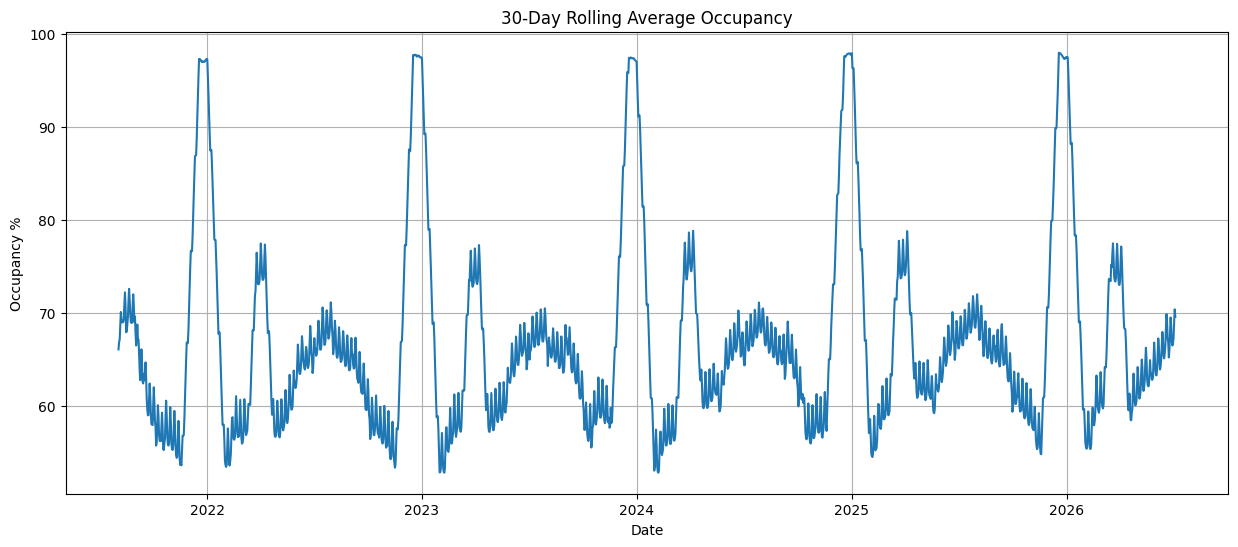

In [8]:
"""
This graph shows how occupancy changed over time.

As a revenue management project, this helps me see seasonality, high-demand periods,
low-demand periods, and any unusual demand spikes.
"""

plt.figure(figsize=(15,6))

rolling_occ = df.set_index("Date")["Occupancy_Pct"].rolling(30).mean()

plt.plot(rolling_occ)

plt.title("30-Day Rolling Average Occupancy")
plt.xlabel("Date")
plt.ylabel("Occupancy %")
plt.grid(True)

plt.show()

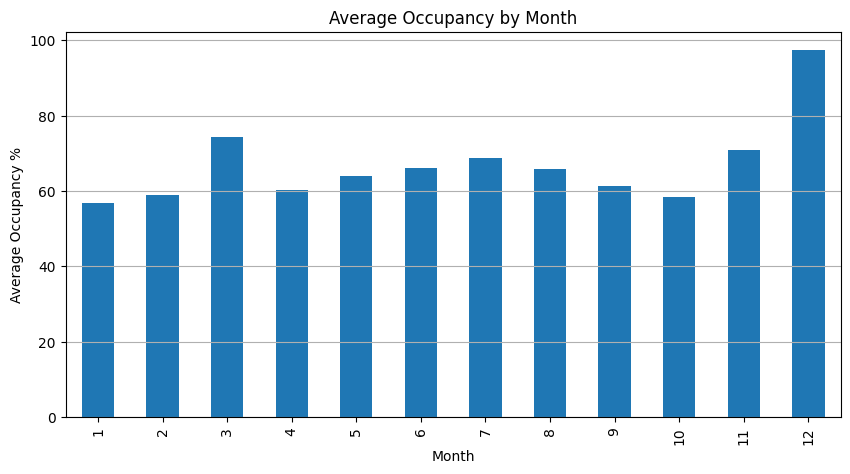

In [9]:
"""
This helps identify monthly seasonality.

For hotels, some months naturally perform better because of summer travel,
holidays, school breaks, events, or local tourism demand.
"""

monthly_occ = df.groupby("Month")["Occupancy_Pct"].mean()

plt.figure(figsize=(10, 5))
monthly_occ.plot(kind="bar")
plt.title("Average Occupancy by Month")
plt.xlabel("Month")
plt.ylabel("Average Occupancy %")
plt.grid(axis="y")
plt.show()

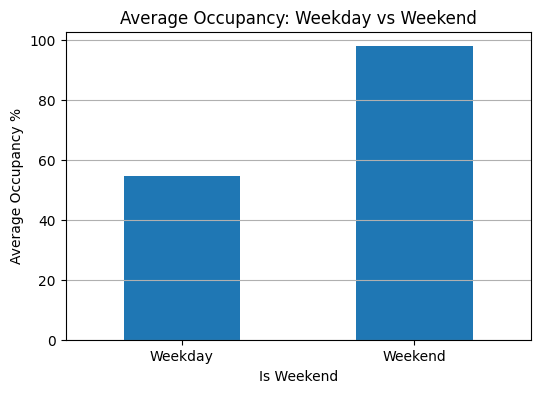

IsWeekend
0    54.736628
1    97.833333
Name: Occupancy_Pct, dtype: float64

In [10]:
"""
This compares weekday and weekend demand.

For a leisure-heavy hotel, Friday and Saturday usually have stronger demand.
This is important because pricing strategy should be different for weekends and weekdays.
"""

weekend_occ = df.groupby("IsWeekend")["Occupancy_Pct"].mean()

plt.figure(figsize=(6, 4))
weekend_occ.plot(kind="bar")
plt.title("Average Occupancy: Weekday vs Weekend")
plt.xlabel("Is Weekend")
plt.ylabel("Average Occupancy %")
plt.xticks([0, 1], ["Weekday", "Weekend"], rotation=0)
plt.grid(axis="y")
plt.show()

display(weekend_occ)

Average Occupancy by Holiday Flag:


IsHoliday
0    66.365809
1    97.615000
Name: Occupancy_Pct, dtype: float64


Average Occupancy by Special Event Flag:


IsSpecialEvent
0    60.809822
1    97.586452
Name: Occupancy_Pct, dtype: float64

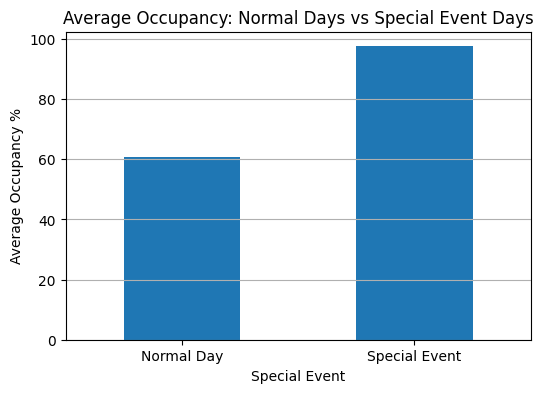

In [11]:
"""
Here I am checking whether holidays and special events increase occupancy.

In hotel revenue management, special events and holidays usually push occupancy higher,
which means ADR can also be optimized.
"""

holiday_occ = df.groupby("IsHoliday")["Occupancy_Pct"].mean()
event_occ = df.groupby("IsSpecialEvent")["Occupancy_Pct"].mean()

print("Average Occupancy by Holiday Flag:")
display(holiday_occ)

print("\nAverage Occupancy by Special Event Flag:")
display(event_occ)

plt.figure(figsize=(6, 4))
event_occ.plot(kind="bar")
plt.title("Average Occupancy: Normal Days vs Special Event Days")
plt.xlabel("Special Event")
plt.ylabel("Average Occupancy %")
plt.xticks([0, 1], ["Normal Day", "Special Event"], rotation=0)
plt.grid(axis="y")
plt.show()

In [12]:
"""
This shows which numeric variables are most related to occupancy.

Correlation does not prove cause and effect, but it gives a useful first idea
of which variables may help the model.
"""

numeric_df = df.select_dtypes(include=["int64", "float64"])

correlation_with_target = numeric_df.corr()["Occupancy_Pct"].sort_values(ascending=False)

print("Top Positive Correlations with Occupancy:")
display(correlation_with_target.head(15))

print("\nTop Negative Correlations with Occupancy:")
display(correlation_with_target.tail(15))

Top Positive Correlations with Occupancy:


Occupancy_Pct                  1.000000
CompSet_Occupancy_Pct          0.990187
OTB_Occupancy_Pct_14dPrior     0.970476
OTB_RoomsSold_14dPrior         0.970352
Booking_Pace_Index_14d         0.964492
CTA_Flag                       0.833449
IsWeekend                      0.726463
CTD_Flag                       0.628784
ADR                            0.609735
Avg_Comp_ADR                   0.607971
BAR_Level                      0.602109
IsSpecialEvent                 0.515079
Minimum_Stay_Nights            0.482777
CruiseShipInPort               0.325593
Weekend_Before_Holiday_Flag    0.284054
Name: Occupancy_Pct, dtype: float64


Top Negative Correlations with Occupancy:


Available_Rooms_For_Sale    0.093054
Group_Wash_Pct              0.069426
Promotion_Running           0.058723
Discount_Pct                0.052022
Maintenance_Rooms           0.008336
RainFlag                   -0.011772
Num_Groups                 -0.012089
Blocked_Rooms              -0.031564
ConventionFlag             -0.037446
HurricaneSeasonFlag        -0.066645
TempF                      -0.084323
OOO_Rooms                  -0.088455
StormImpact                -0.089477
Days_Until_Next_Holiday    -0.209992
Group_Rooms                -0.281976
Name: Occupancy_Pct, dtype: float64

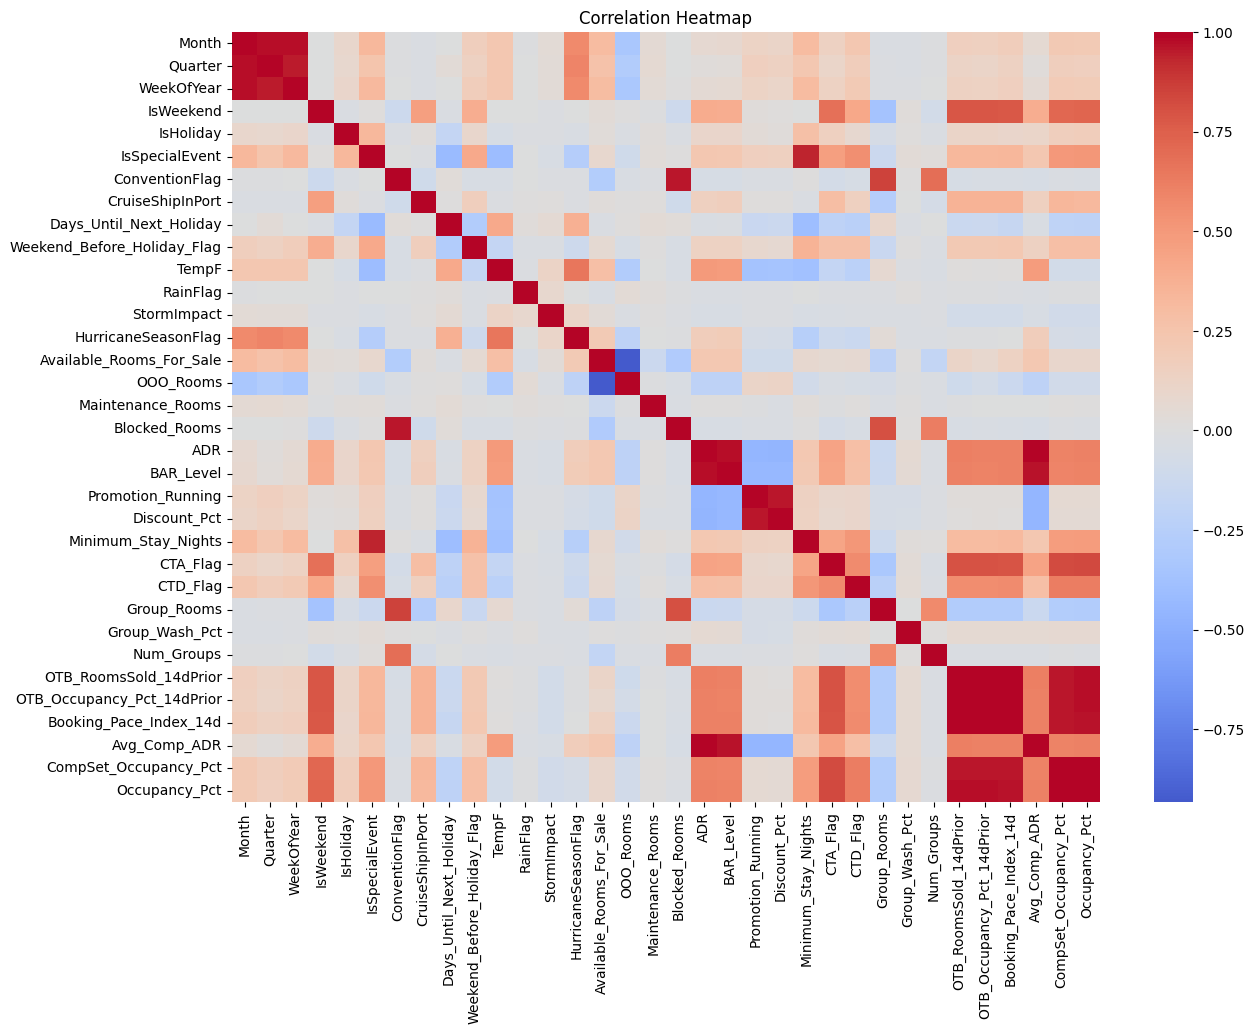

In [13]:
"""
The heatmap helps identify relationships between numerical variables.

If many columns are strongly related to each other, it means the model may be seeing repeated information.
"""

plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

In [14]:
"""
Now I am separating the target variable and input features.

Target variable:
Occupancy_Pct

Input features:
All selected columns except Date and Occupancy_Pct.

Date is not directly used in the model because we already extracted useful date features like Month,
WeekOfYear, DayOfWeek, and Season.
"""

target = "Occupancy_Pct"

X = df.drop(columns=["Date", target])
y = df[target]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1827, 35)
Target Shape: (1827,)


In [15]:
"""
Since this is a forecasting project, I should not randomly split the data.

The model should train on older dates and test on newer dates.
This better represents real hotel forecasting, where we use past data to predict future demand.
"""

split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 1461
Testing Rows: 366


In [16]:
"""
Machine Learning models need clean numerical inputs.

Numerical columns:
Missing values are filled using median.

Categorical columns:
Missing values are filled with most frequent value.
Then they are converted into numbers using One Hot Encoding.

This pipeline keeps preprocessing organized and reusable.
"""

numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric Features:", numeric_features)
print("\nCategorical Features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Numeric Features: ['Month', 'Quarter', 'WeekOfYear', 'IsWeekend', 'IsHoliday', 'IsSpecialEvent', 'ConventionFlag', 'CruiseShipInPort', 'Days_Until_Next_Holiday', 'Weekend_Before_Holiday_Flag', 'TempF', 'RainFlag', 'StormImpact', 'HurricaneSeasonFlag', 'Available_Rooms_For_Sale', 'OOO_Rooms', 'Maintenance_Rooms', 'Blocked_Rooms', 'ADR', 'BAR_Level', 'Promotion_Running', 'Discount_Pct', 'Minimum_Stay_Nights', 'CTA_Flag', 'CTD_Flag', 'Group_Rooms', 'Group_Wash_Pct', 'Num_Groups', 'OTB_RoomsSold_14dPrior', 'OTB_Occupancy_Pct_14dPrior', 'Booking_Pace_Index_14d', 'Avg_Comp_ADR', 'CompSet_Occupancy_Pct']

Categorical Features: ['DayOfWeek', 'Season']


In [17]:
"""
Here I am creating multiple models.

I am not depending on only one model because different algorithms learn patterns differently.

Linear Regression is simple.
Decision Tree is easy to understand.
Random Forest and Extra Trees are stronger tree-based models.
Gradient Boosting is usually strong for tabular hotel data.
"""

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(n_estimators=300, random_state=42)
}

In [18]:
"""
Now I am training each model and calculating evaluation metrics.

MAE tells me, on average, how many occupancy percentage points the model is off.

RMSE gives more penalty to large errors.

MAPE shows average percentage error.

R2 shows how much of the occupancy movement the model can explain.
"""

def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    non_zero = y_true != 0
    return np.mean(np.abs((y_true[non_zero] - y_pred[non_zero]) / y_true[non_zero])) * 100


results = []
trained_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2
    })
    
    trained_pipelines[model_name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="MAE")

display(results_df)

,Model,MAE,RMSE,MAPE,R2
4,Extra Trees,1.187759,1.532095,2.164854,0.996569
2,Random Forest,1.265437,1.642141,2.287576,0.996059
3,Gradient Boosting,1.270741,1.694999,2.313266,0.995801
1,Decision Tree,1.691803,2.267916,3.076400,0.992483
0,Linear Regression,1.842916,2.344393,3.000386,0.991967


In [19]:
"""
The best model is selected based on the lowest MAE.

For occupancy forecasting, MAE is very easy to explain:
If MAE is 5, the model is off by around 5 occupancy percentage points on average.
"""

best_model_name = results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("Best Model:", best_model_name)
display(results_df.iloc[0])

Best Model: Extra Trees


Model    Extra Trees
MAE         1.187759
RMSE        1.532095
MAPE        2.164854
R2          0.996569
Name: 4, dtype: object

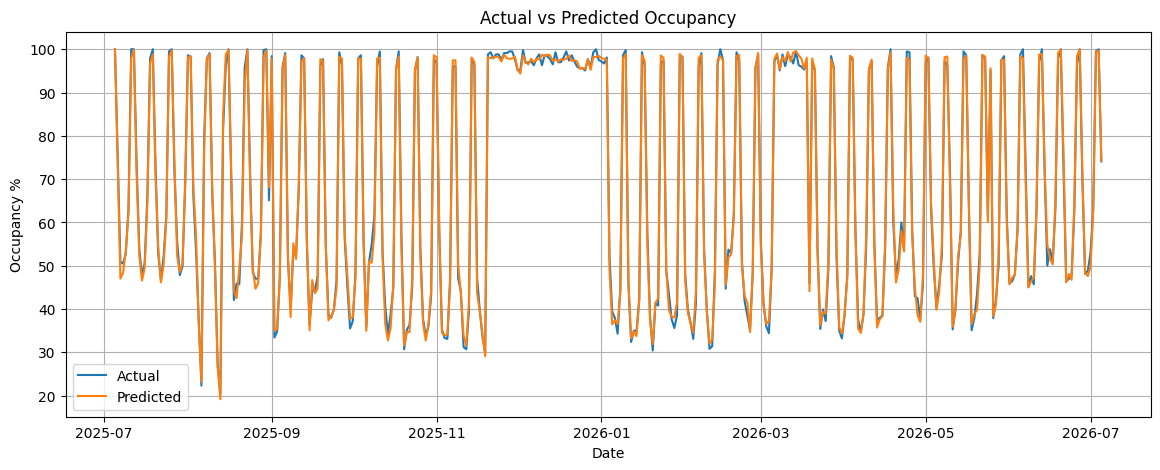

,Date,Actual_Occupancy,Predicted_Occupancy
0,2025-07-05,100.0,99.959333
1,2025-07-06,75.5,74.089333
2,2025-07-07,50.9,47.023000
3,2025-07-08,50.5,48.316333
4,2025-07-09,52.7,53.508333


In [20]:
"""
This chart compares actual occupancy with predicted occupancy.

If the lines are close, the model is performing well.
If they are far apart, the model is missing some demand patterns.
"""

y_pred_best = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Date": df.iloc[split_index:]["Date"].values,
    "Actual_Occupancy": y_test.values,
    "Predicted_Occupancy": y_pred_best
})

plt.figure(figsize=(14, 5))
plt.plot(comparison_df["Date"], comparison_df["Actual_Occupancy"], label="Actual")
plt.plot(comparison_df["Date"], comparison_df["Predicted_Occupancy"], label="Predicted")
plt.title("Actual vs Predicted Occupancy")
plt.xlabel("Date")
plt.ylabel("Occupancy %")
plt.legend()
plt.grid(True)
plt.show()

display(comparison_df.head())

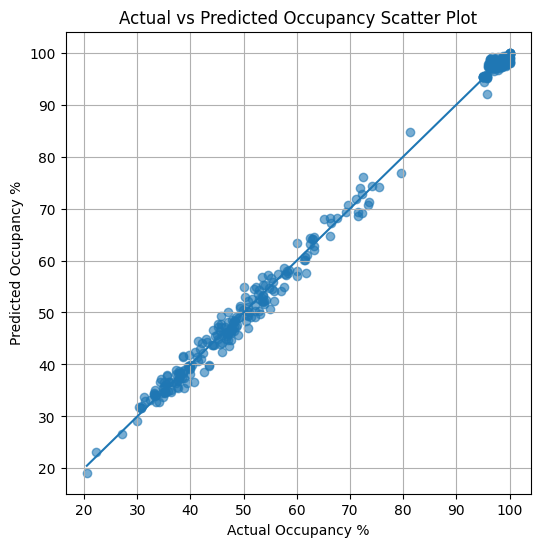

In [21]:
"""
This scatter plot shows how close predictions are to actual occupancy.

The closer the dots are to the diagonal line, the better the model is.
"""

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title("Actual vs Predicted Occupancy Scatter Plot")
plt.xlabel("Actual Occupancy %")
plt.ylabel("Predicted Occupancy %")
plt.grid(True)
plt.show()

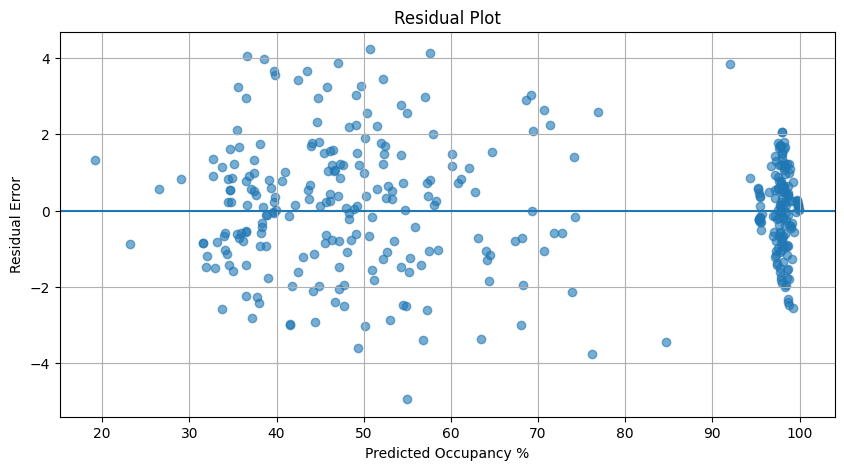

In [22]:
"""
Residual means prediction error.

Residual = Actual Occupancy - Predicted Occupancy

This helps me understand if the model is overpredicting or underpredicting.
"""

residuals = y_test - y_pred_best

plt.figure(figsize=(10, 5))
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(0)
plt.title("Residual Plot")
plt.xlabel("Predicted Occupancy %")
plt.ylabel("Residual Error")
plt.grid(True)
plt.show()

,Feature,Importance
32,num__CompSet_Occupancy_Pct,0.399067
28,num__OTB_RoomsSold_14dPrior,0.174395
29,num__OTB_Occupancy_Pct_14dPrior,0.169585
30,num__Booking_Pace_Index_14d,0.143956
23,num__CTA_Flag,0.101119
5,num__IsSpecialEvent,0.002846
36,cat__DayOfWeek_Sunday,0.001447
19,num__BAR_Level,0.000872
31,num__Avg_Comp_ADR,0.000849
3,num__IsWeekend,0.000692


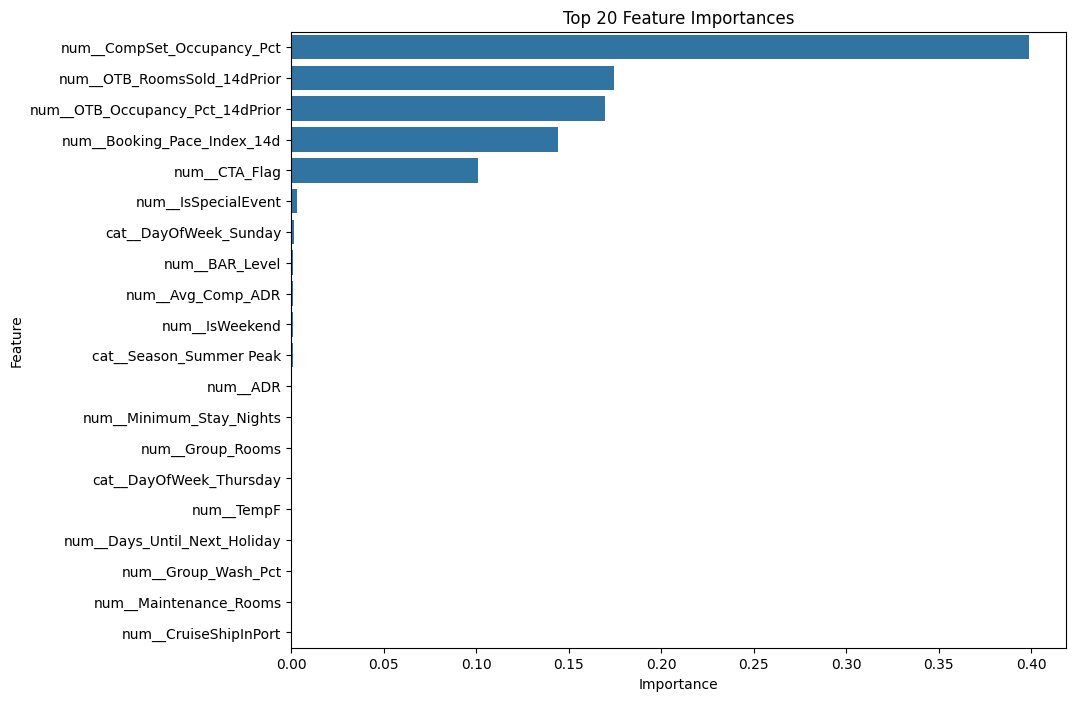

In [23]:
"""
Tree-based models can show which features were most important.

This helps translate the model into hotel business language.
For example, if OTB occupancy, ADR, weekend, and comp set occupancy are important,
that makes sense from a revenue management point of view.
"""

model_step = best_model.named_steps["model"]

if hasattr(model_step, "feature_importances_"):
    
    feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
    importances = model_step.feature_importances_
    
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    display(feature_importance_df.head(20))
    
    plt.figure(figsize=(10, 8))
    sns.barplot(
        data=feature_importance_df.head(20),
        x="Importance",
        y="Feature"
    )
    plt.title("Top 20 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.show()

else:
    print("Feature importance is not available for this model.")

In [ ]:
"""
Now I am saving the best model.

This is important because after training, I do not want to retrain the model every time.
I can load the saved model and use it for future occupancy predictions.
"""

joblib.dump(best_model, "occupancy_forecasting_model.pkl")
joblib.dump(X.columns.tolist(), "selected_feature_columns.pkl")
results_df.to_csv("model_evaluation_metrics.csv", index=False)

print("Model saved as occupancy_forecasting_model.pkl")
print("Feature list saved as selected_feature_columns.pkl")
print("Metrics saved as model_evaluation_metrics.csv")